!pip install nats_bench

In [35]:
import os
import tarfile
from nats_bench import create

# ── PATH CONFIG ──────────────────────────────────────────────────────────
# Questo notebook sta in progetto-deeplearning/latent_space/
# I dataset stanno in progetto-deeplearning/datasets/
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

# Estrazione archivio (solo la prima volta)
if not os.path.exists(DATASET_PATH):
    print('Estrazione in corso...')
    with tarfile.open(percorso_tar, 'r') as tar:
        tar.extractall(path=DATASETS_DIR)
    print('Estrazione completata!')
else:
    print('Dataset già estratto.')

# Caricamento API NATS-Bench TSS
api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


In [36]:
import torch
import numpy as np
import random

seed = 42

# Python random
random.seed(seed)

# NumPy
np.random.seed(seed)

# PyTorch CPU
torch.manual_seed(seed)

# PyTorch GPU (se usi CUDA)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# per riproducibilità più forte (può rallentare)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## API inspection 

un elemento del dataset:
- DAG dell'architettura in cui ogni nodo è una cella di operazioni (conv, max pooling..)
- risultati su vari datasets e su regime brene e lungo di training 

In [37]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382 & top1 = 86.97%], valid : [loss = 0.514 & top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243 & top1 = 91.69%], test  : [loss = 0.362 & top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271 & top1 = 63.76%], valid : [loss = 1.495 & top1 = 57.80%], test : [loss = 1.478 & top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548 & top1 = 35.41%], valid : [loss = 2.580 & top1 = 35.43%], test : [loss = 2.611 & top1 = 33.80%]
>>>>>>>>

## API inspection

Un elemento del dataset NATS-Bench TSS:
- la stringa architettura descrive operazioni su un DAG a 4 nodi
  (stesso formato di NAS-Bench-201, ma senza pesi salvati)
- risultati disponibili su cifar10, cifar100, ImageNet16-120


per vedere risultati su un datasets e una specifica architettura 

In [38]:
# Mostra info per un'architettura specifica
idx = 1

# Accuracy su cifar10
info_cifar10 = api.get_more_info(idx, 'cifar10', is_random=False)
print('cifar10  test-accuracy:', info_cifar10.get('test-accuracy'))

# Accuracy su cifar100
info_cifar100 = api.get_more_info(idx, 'cifar100', is_random=False)
print('cifar100 test-accuracy:', info_cifar100.get('test-accuracy'))


cifar10  test-accuracy: 88.22
cifar100 test-accuracy: 58.25999995727539


## API inspection

Un elemento del dataset NATS-Bench TSS:
- la stringa architettura descrive operazioni su un DAG a 4 nodi
  (stesso formato di NAS-Bench-201, ma senza pesi salvati)
- risultati disponibili su cifar10, cifar100, ImageNet16-120


In [39]:
# Stringa architettura TSS: canali di ogni layer
print(api[0])


|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


In [40]:
import numpy as np
import re

OPS = {
    'nor_conv_3x3': 0,
    'nor_conv_1x1': 1,
    'skip_connect': 2,
    'avg_pool_3x3': 3,
    'none':         4,
    'zeroize':      5,
}

def arch_to_tensor(arch_str):
    """
    Converte una stringa NATS-Bench TSS / NAS-Bench-201
    (es. '|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+...')
    in un tensore A[op, src, dst] di shape (6, 4, 4).
    Flattened: 6*4*4 = 96 valori.
    """
    nodes = arch_str.strip('|').split('+')
    N = len(nodes) + 1  # nodi totali (input + intermedi)
    K = len(OPS)
    A = np.zeros((K, N, N), dtype=np.float32)
    for dst, node in enumerate(nodes, start=1):
        edges = re.findall(
            r'(' + '|'.join(OPS.keys()) + r')~(\d)',
            node
        )
        for op_name, src_node in edges:
            A[OPS[op_name], int(src_node), dst] = 1.0
    return A


In [41]:
arch_to_tensor(arch_str=api[0])


array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 1., 1.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 0., 1.],
        [0., 0., 0., 0.]],

       [[0., 1., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]], dtype=float32)

In [42]:
all_tensors = []

for i in range(len(api)):
    arch_str = api[i]
    A = arch_to_tensor(arch_str)
    all_tensors.append(A)

X = np.stack(all_tensors)  # shape: (N_architetture, 6, 4, 4)
print('X shape:', X.shape)


X shape: (15625, 6, 4, 4)


In [43]:
import torch
X = torch.tensor(X)       # shape: (N_architetture, 6, 4, 4)
X = X.view(len(X), -1)    # flatten → (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


In [44]:
# Verifica shape: dovrebbe essere (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

LATENT_DIM = 16
INPUT_DIM = 96   # 6 ops * 4 nodi * 4 nodi (tensore flattened)


class VAE(nn.Module):

    def __init__(self):

        super().__init__()

        # encoder
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)

        self.mu = nn.Linear(64, LATENT_DIM)
        self.logvar = nn.Linear(64, LATENT_DIM)

        # decoder
        self.fc3 = nn.Linear(LATENT_DIM, 64)
        self.fc4 = nn.Linear(64, 128)
        self.fc5 = nn.Linear(128, INPUT_DIM)

    def encode(self, x):

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        h = F.relu(self.fc3(z))
        h = F.relu(self.fc4(h))

        return torch.sigmoid(self.fc5(h))

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

In [46]:
import torch.nn.functional as F

def vae_loss(recon, x, mu, logvar,beta=1):

    # ricostruzione
    recon_loss = F.binary_cross_entropy(
        recon,
        x,
        reduction='sum'
    )

    # KL divergence
    kl = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl * beta

In [47]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

In [48]:
model = VAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

model.train()

for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0]

        # forward
        recon, mu, logvar = model(x)

        loss = vae_loss(recon, x, mu, logvar,beta=1.5)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f}")

Epoch 1 | Loss: 386436.78
Epoch 2 | Loss: 238200.00
Epoch 3 | Loss: 237216.50
Epoch 4 | Loss: 236806.37
Epoch 5 | Loss: 236486.19
Epoch 6 | Loss: 236304.23
Epoch 7 | Loss: 236138.58
Epoch 8 | Loss: 235809.35
Epoch 9 | Loss: 235711.70
Epoch 10 | Loss: 235606.50
Epoch 11 | Loss: 235472.55
Epoch 12 | Loss: 235370.58
Epoch 13 | Loss: 235324.44
Epoch 14 | Loss: 235217.71
Epoch 15 | Loss: 235191.97
Epoch 16 | Loss: 235183.17
Epoch 17 | Loss: 235048.53
Epoch 18 | Loss: 235106.85
Epoch 19 | Loss: 235047.84
Epoch 20 | Loss: 235047.64
Epoch 21 | Loss: 235018.20
Epoch 22 | Loss: 234959.08
Epoch 23 | Loss: 234979.14
Epoch 24 | Loss: 234971.17
Epoch 25 | Loss: 234970.02
Epoch 26 | Loss: 234959.65
Epoch 27 | Loss: 234920.92
Epoch 28 | Loss: 234917.65
Epoch 29 | Loss: 234851.39
Epoch 30 | Loss: 234828.02
Epoch 31 | Loss: 234857.38
Epoch 32 | Loss: 234836.75
Epoch 33 | Loss: 234887.30
Epoch 34 | Loss: 234812.00
Epoch 35 | Loss: 234826.11
Epoch 36 | Loss: 234799.15
Epoch 37 | Loss: 234760.56
Epoch 38 |

In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

model.eval()

with torch.no_grad():

    mu, logvar = model.encode(X)

    z = mu   # embedding stabile
z = z.numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d = pca.fit_transform(z)


In [50]:
acc = {}
for i in range(len(api)):
    info = api.get_more_info(i, 'cifar100', is_random=False)
    acc[i] = info.get('test-accuracy', 0.0)


C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\nats_bench\api_utils.py:116: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(cfile)  # pytype: disable=wrong-arg-types


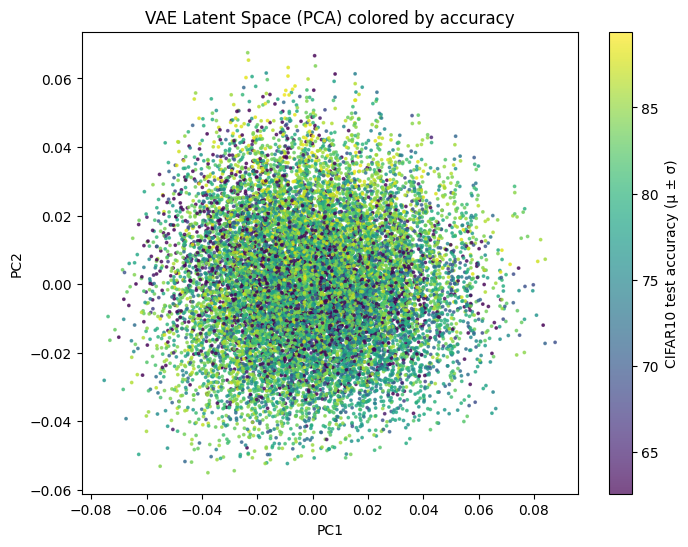

In [51]:
# ----------------------------
# 1. ESTRAI ACCURACY
# ----------------------------
import numpy as np

acc = np.zeros(len(api))

for i in range(len(api)):
    info = api.get_more_info(i, 'cifar10', is_random=False)
    acc[i] = info.get('test-accuracy', 0.0)

acc = np.array(acc)

# ----------------------------
# 2. STATISTICHE
# ----------------------------
mu_acc = np.mean(acc)
std_acc = np.std(acc)

vmin = mu_acc - std_acc
vmax = mu_acc + std_acc

# ----------------------------
# 4. PLOT
# ----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sc = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=acc,
    cmap='viridis',
    s=3,
    alpha=0.7,
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(sc, label='CIFAR10 test accuracy (μ ± σ)')
plt.title('VAE Latent Space (PCA) colored by accuracy')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
